# 01 Filtering — Empatica E4 + RespiBAN
Data is loaded via the external `data_loader.py` module. All plots are saved under `Data/Plots/<Device>/<Signal>/`.

In [24]:
# Setup: external data loader, config, plot-saving helpers
import sys
from pathlib import Path

sys.path.append("..")   # so data_loader.py (repo root) is importable
import wesad_data_loader as dl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, sosfiltfilt, find_peaks, savgol_filter
from scipy.stats import zscore, linregress

SUBJECT = "S2"

PLOTS_ROOT = Path("output")          # <- lives inside 01_filtering/, NOT Data/
PLOT_FOLDERS = [
    "E4/BVP", "E4/EDA", "E4/HR", "E4/IBI", "E4/TEMP", "E4/ACC",
    "RespiBAN/ECG", "RespiBAN/EDA", "RespiBAN/EMG", "RespiBAN/RESP", "RespiBAN/TEMP", "RespiBAN/ACC",
]
for folder in PLOT_FOLDERS:
    (PLOTS_ROOT / folder).mkdir(parents=True, exist_ok=True)

PREPROCESSED_ROOT = Path("../Data/preprocessed_data")
for folder in ["filtered", "normalized", "windows_raw", "windows_filtered", "windows_normalized"]:
    (PREPROCESSED_ROOT / folder).mkdir(parents=True, exist_ok=True)


def save_and_show(filename: str):
    """Save the current matplotlib figure to PLOTS_ROOT/filename, then display it."""
    path = PLOTS_ROOT / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path.resolve()}")
    plt.show()

## EMPATICA (E4)

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\BVP\S2_raw_vs_filtered.png


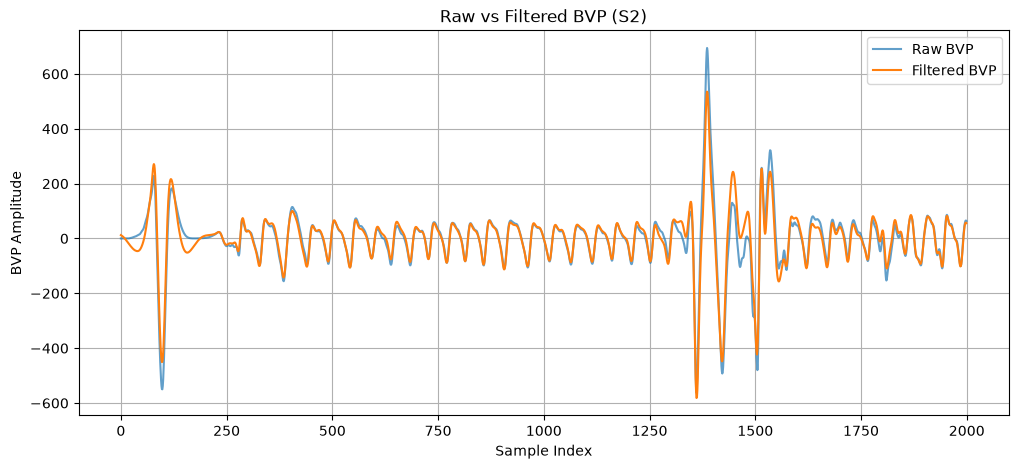

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\BVP\S2_filtered_zoom.png


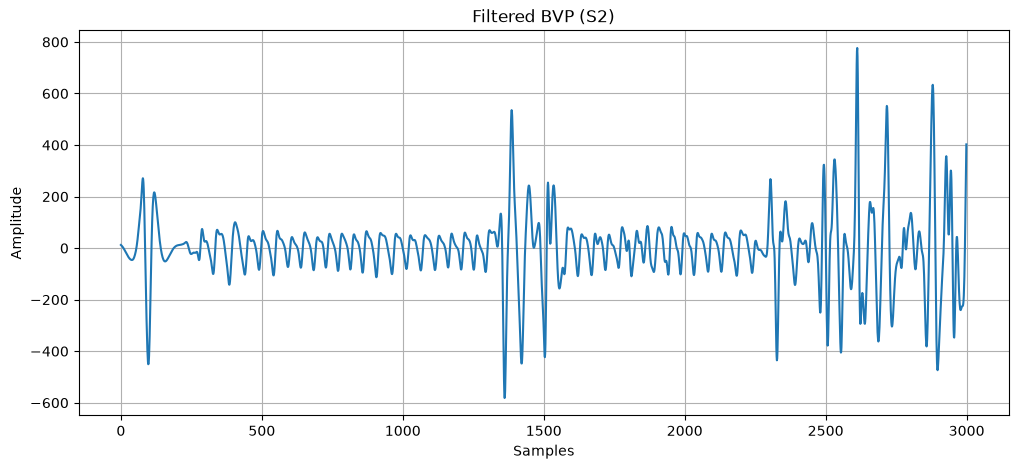

           Metric        Raw   Filtered
0            Mean     0.0036     0.0002
1             Std    82.6816    70.2994
2  Spikes (>3std) 13689.0000 13742.0000
3  Noise Estimate    12.7887    11.5613
4      Peak Count  9719.0000  9548.0000


In [25]:
# 01 Filtering and Analysis - EMPATICA BVP
bvp, fs_bvp = dl.load_e4_signal(SUBJECT, "BVP")

# Butterworth bandpass filter
fs = fs_bvp
lowcut, highcut = 0.7, 5
nyquist = fs / 2
b, a = butter(4, [lowcut / nyquist, highcut / nyquist], btype="band")
bvp_filtered = filtfilt(b, a, bvp)

# --- Plot: raw vs filtered ---
plt.figure(figsize=(12, 5))
samples = 2000
plt.plot(bvp[:samples], label="Raw BVP", alpha=0.7)
plt.plot(bvp_filtered[:samples], label="Filtered BVP")
plt.title(f"Raw vs Filtered BVP ({SUBJECT})")
plt.xlabel("Sample Index")
plt.ylabel("BVP Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"E4/BVP/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: filtered only, zoomed ---
plt.figure(figsize=(12, 5))
plt.plot(bvp_filtered[0:3000], label="Filtered BVP")
plt.title(f"Filtered BVP ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
save_and_show(f"E4/BVP/{SUBJECT}_filtered_zoom.png")

# --- Quality metrics ---
raw_z = np.abs((bvp - np.mean(bvp)) / np.std(bvp))
filtered_z = np.abs((bvp_filtered - np.mean(bvp_filtered)) / np.std(bvp_filtered))
raw_spikes = np.sum(raw_z > 3)
filtered_spikes = np.sum(filtered_z > 3)
noise_raw = np.std(np.diff(bvp))
noise_filtered = np.std(np.diff(bvp_filtered))

raw_peaks, _ = find_peaks(bvp, prominence=0.1, distance=int(fs / 2))
filtered_peaks, _ = find_peaks(bvp_filtered, prominence=0.1, distance=int(fs / 2))

results = pd.DataFrame({
    "Metric": ["Mean", "Std", "Spikes (>3std)", "Noise Estimate", "Peak Count"],
    "Raw": [np.mean(bvp), np.std(bvp), raw_spikes, noise_raw, len(raw_peaks)],
    "Filtered": [np.mean(bvp_filtered), np.std(bvp_filtered), filtered_spikes, noise_filtered, len(filtered_peaks)],
})
print(results)


Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\EDA\S2_filtered.png


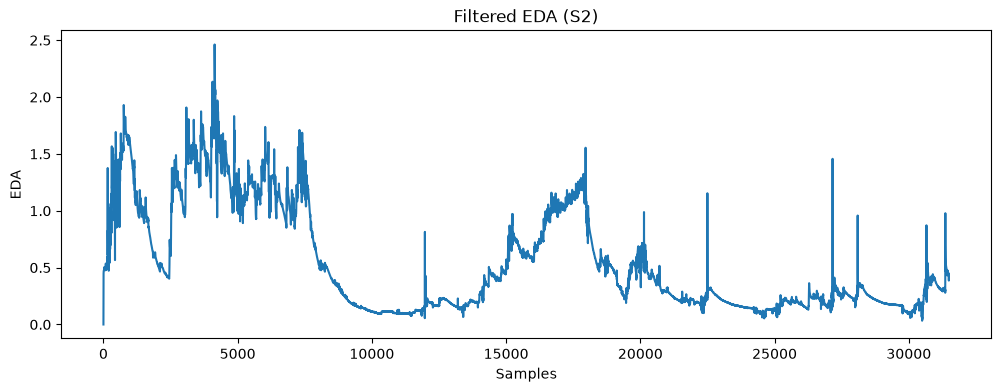

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\EDA\S2_raw_vs_filtered.png


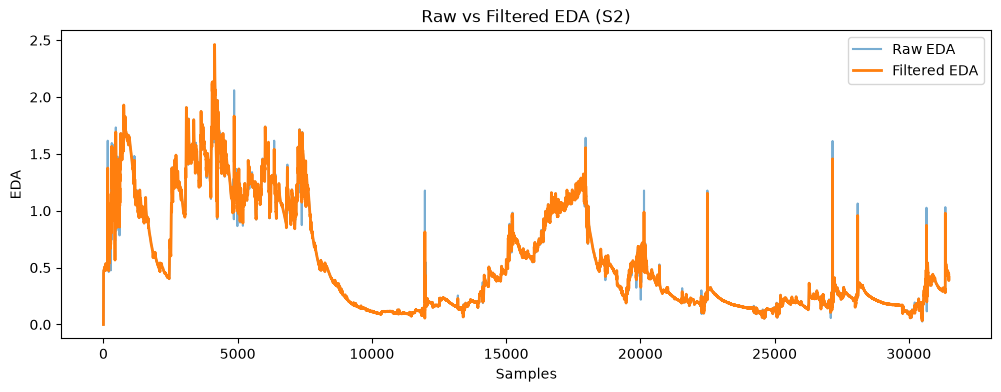

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\EDA\S2_raw_vs_filtered_zoom.png


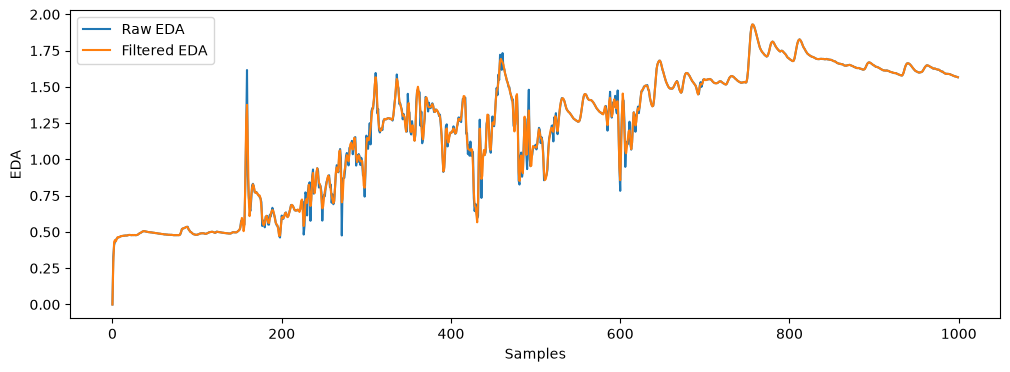

========== RAW EDA ==========
Samples   : 31494
Mean      : 0.5478223880104146
Std       : 0.46081414615229327
Noise     : 0.024727757661578493
Spikes    : 430
Peaks     : 753
Drift     : -3.201999789040934e-05

========== FILTERED EDA ==========
Samples   : 31494
Mean      : 0.5478219366606292
Std       : 0.4606991855891192
Noise     : 0.017869333467055756
Spikes    : 499
Peaks     : 576
Drift     : -3.201988431807015e-05


In [26]:
# 02 EDA - EMPATICA
eda_raw, fs_eda = dl.load_e4_signal(SUBJECT, "EDA")

def lowpass_filter(sig, cutoff, fs, order=4):
    nyquist = fs / 2
    b, a = butter(order, cutoff / nyquist, btype="low")
    return filtfilt(b, a, sig)

eda_filtered = lowpass_filter(eda_raw, cutoff=1, fs=fs_eda)

# --- Plot: filtered only ---
plt.figure(figsize=(12, 4))
plt.plot(eda_filtered)
plt.title(f"Filtered EDA ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("EDA")
save_and_show(f"E4/EDA/{SUBJECT}_filtered.png")

# --- Plot: raw vs filtered, full ---
plt.figure(figsize=(12, 4))
plt.plot(eda_raw, label="Raw EDA", alpha=0.6)
plt.plot(eda_filtered, label="Filtered EDA", linewidth=2)
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.legend()
plt.title(f"Raw vs Filtered EDA ({SUBJECT})")
save_and_show(f"E4/EDA/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: raw vs filtered, zoomed ---
plt.figure(figsize=(12, 4))
plt.plot(eda_raw[:1000], label="Raw EDA")
plt.plot(eda_filtered[:1000], label="Filtered EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.legend()
save_and_show(f"E4/EDA/{SUBJECT}_raw_vs_filtered_zoom.png")

# --- Quality metrics ---
def calculate_noise(sig):
    return np.std(np.diff(sig))

def count_spikes(sig, threshold=3):
    diff_signal = np.abs(np.diff(sig))
    spike_threshold = threshold * np.std(diff_signal)
    return np.sum(diff_signal > spike_threshold)

def count_peaks(sig, prominence=0.02):
    peaks, _ = find_peaks(sig, prominence=prominence)
    return len(peaks)

def calculate_drift(sig):
    x = np.arange(len(sig))
    slope, _, _, _, _ = linregress(x, sig)
    return slope

def get_metrics(sig):
    return {
        "Samples": len(sig), "Mean": np.mean(sig), "Std": np.std(sig),
        "Noise": calculate_noise(sig), "Spikes": count_spikes(sig),
        "Peaks": count_peaks(sig), "Drift": calculate_drift(sig),
    }

raw_metrics = get_metrics(eda_raw)
filtered_metrics = get_metrics(eda_filtered)

print("========== RAW EDA ==========")
for key, value in raw_metrics.items():
    print(f"{key:<10}: {value}")
print("\n========== FILTERED EDA ==========")
for key, value in filtered_metrics.items():
    print(f"{key:<10}: {value}")


========== RAW HR ==========
Mean      : 75.09649459631277
Std       : 10.736697505251097
Spikes    : 224
Noise     : 0.3000398582891357
Drift     : -0.0011579986425533173

========== FILTERED HR ==========
Mean      : 75.09649217195201
Std       : 10.736027595230649
Spikes    : 223
Noise     : 0.2690668136252866
Drift     : -0.0011579963662164282

========== IMPROVEMENT ==========
Noise Reduction (%) : 10.322976700649447
Std Reduction (%) : 0.006239442064200317
Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\HR\S2_raw_vs_filtered.png


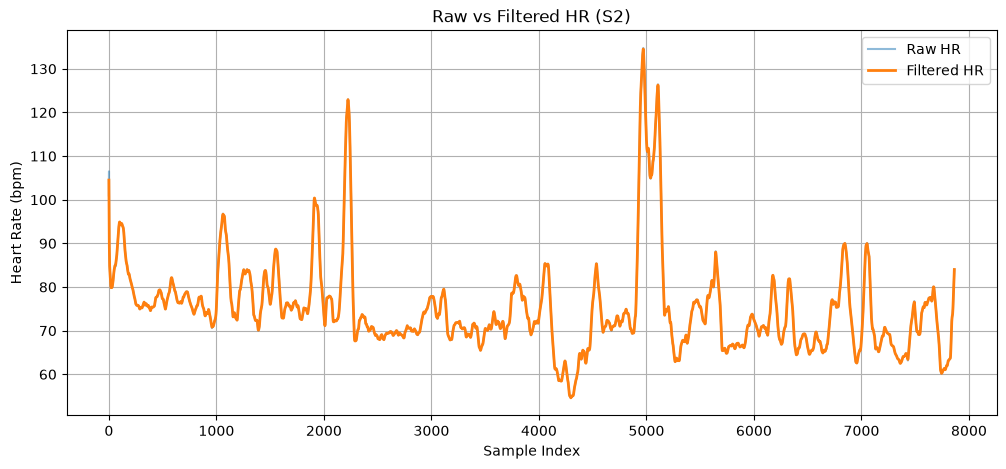

In [27]:
# 03 HR - EMPATICA
hr, fs_hr = dl.load_e4_signal(SUBJECT, "HR")

hr_filtered = savgol_filter(hr, window_length=11, polyorder=2)

def calculate_noise(sig):
    return np.std(np.diff(sig))

def count_spikes(sig, threshold=3):
    z = np.abs(zscore(sig))
    return np.sum(z > threshold)

def calculate_drift(sig):
    x = np.arange(len(sig))
    slope, _, _, _, _ = linregress(x, sig)
    return slope

raw_mean, raw_std = np.mean(hr), np.std(hr)
raw_noise, raw_spikes, raw_drift = calculate_noise(hr), count_spikes(hr), calculate_drift(hr)

filt_mean, filt_std = np.mean(hr_filtered), np.std(hr_filtered)
filt_noise, filt_spikes, filt_drift = calculate_noise(hr_filtered), count_spikes(hr_filtered), calculate_drift(hr_filtered)

print("========== RAW HR ==========")
print("Mean      :", raw_mean)
print("Std       :", raw_std)
print("Spikes    :", raw_spikes)
print("Noise     :", raw_noise)
print("Drift     :", raw_drift)
print("\n========== FILTERED HR ==========")
print("Mean      :", filt_mean)
print("Std       :", filt_std)
print("Spikes    :", filt_spikes)
print("Noise     :", filt_noise)
print("Drift     :", filt_drift)
print("\n========== IMPROVEMENT ==========")
print("Noise Reduction (%) :", ((raw_noise - filt_noise) / raw_noise) * 100)
print("Std Reduction (%) :", ((raw_std - filt_std) / raw_std) * 100)

# --- Plot: raw vs filtered ---
plt.figure(figsize=(12, 5))
plt.plot(hr, label="Raw HR", alpha=0.5)
plt.plot(hr_filtered, label="Filtered HR", linewidth=2)
plt.title(f"Raw vs Filtered HR ({SUBJECT})")
plt.xlabel("Sample Index")
plt.ylabel("Heart Rate (bpm)")
plt.legend()
plt.grid()
save_and_show(f"E4/HR/{SUBJECT}_raw_vs_filtered.png")



===== IBI QUALITY METRICS =====

Mean IBI       | Raw: 0.854326 | Filtered: 0.854118
Std IBI        | Raw: 0.089570 | Filtered: 0.074614
Outliers       | Raw: 12 | Filtered: 3
Noise          | Raw: 0.077135 | Filtered: 0.028177
Smoothness     | Raw: 0.056419 | Filtered: 0.016042
Consistency    | Raw: 0.104843 | Filtered: 0.087358
Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\IBI\S2_raw_vs_filtered.png


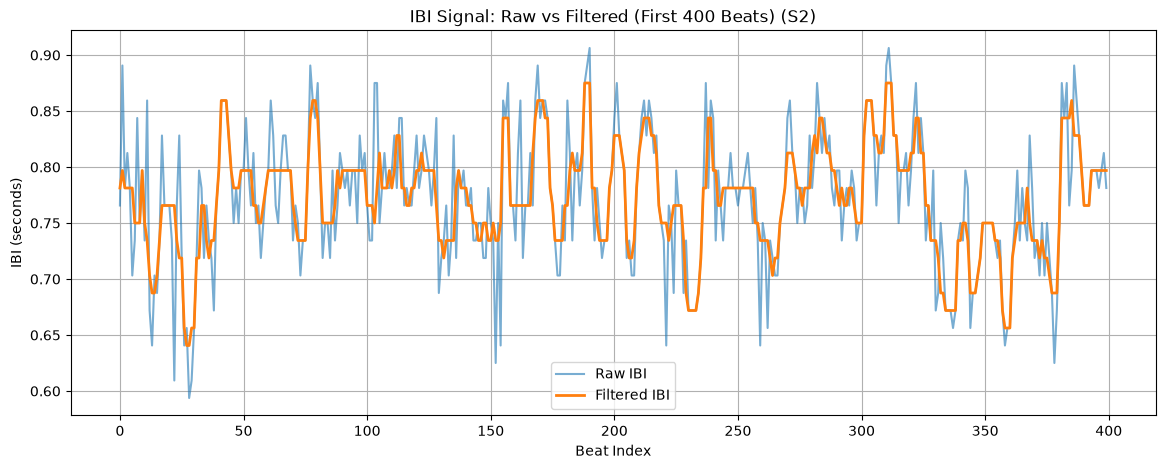

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\IBI\S2_zoomed.png


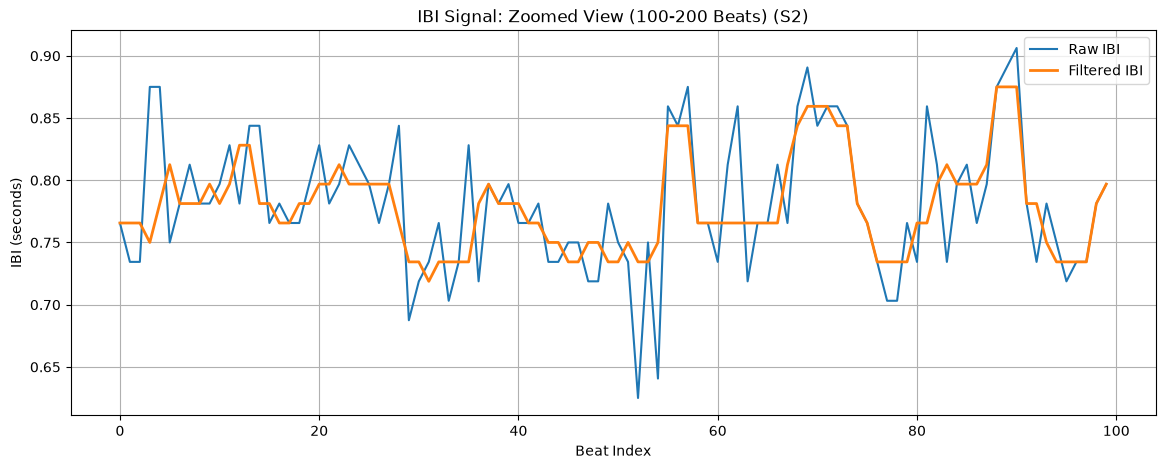

In [28]:
# 04 IBI - EMPATICA
raw_ibi = dl.load_e4_ibi(SUBJECT)

# Interpolation
ibi_interp = pd.Series(raw_ibi).interpolate().bfill().ffill().values

# Smoothing (rolling median)
ibi_filtered = pd.Series(ibi_interp).rolling(window=5, center=True, min_periods=1).median().values

# Align
n = min(len(raw_ibi), len(ibi_filtered))
raw = raw_ibi[:n]
filtered = ibi_filtered[:n]

# Quality metrics
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))
spikes_raw = np.sum(np.abs(zscore(raw)) > 3)
spikes_filtered = np.sum(np.abs(zscore(filtered)) > 3)
smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))
mean_raw, mean_filtered = np.mean(raw), np.mean(filtered)
std_raw, std_filtered = np.std(raw), np.std(filtered)
cv_raw = std_raw / mean_raw
cv_filtered = std_filtered / mean_filtered

print("\n===== IBI QUALITY METRICS =====\n")
print(f"Mean IBI       | Raw: {mean_raw:.6f} | Filtered: {mean_filtered:.6f}")
print(f"Std IBI        | Raw: {std_raw:.6f} | Filtered: {std_filtered:.6f}")
print(f"Outliers       | Raw: {spikes_raw} | Filtered: {spikes_filtered}")
print(f"Noise          | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Smoothness     | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")
print(f"Consistency    | Raw: {cv_raw:.6f} | Filtered: {cv_filtered:.6f}")

# --- Plot: full comparison ---
plt.figure(figsize=(14, 5))
plt.plot(raw[:400], label="Raw IBI", alpha=0.6)
plt.plot(filtered[:400], label="Filtered IBI", linewidth=2)
plt.title(f"IBI Signal: Raw vs Filtered (First 400 Beats) ({SUBJECT})")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
save_and_show(f"E4/IBI/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: zoomed view ---
start, end = 100, 200
plt.figure(figsize=(14, 5))
plt.plot(raw[start:end], label="Raw IBI")
plt.plot(filtered[start:end], label="Filtered IBI", linewidth=2)
plt.title(f"IBI Signal: Zoomed View (100-200 Beats) ({SUBJECT})")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
save_and_show(f"E4/IBI/{SUBJECT}_zoomed.png")



===== TEMPERATURE METRICS =====

Mean       | Raw: 34.569931 | Filtered: 34.569931
Std        | Raw: 1.014642 | Filtered: 1.014618
Min        | Raw: 32.310000 | Filtered: 32.311745
Max        | Raw: 35.970000 | Filtered: 35.967632
Range      | Raw: 3.660000 | Filtered: 3.655887
Noise      | Raw: 0.009895 | Filtered: 0.004522
Drift      | Raw: -0.000073 | Filtered: -0.000073

===== PERCENT CHANGE =====

Mean      : -0.00%
Std       : -0.00%
Min       : 0.01%
Max       : -0.01%
Range     : -0.11%
Noise     : -54.30%
Drift     : 0.00%
Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\TEMP\S2_raw_vs_filtered.png


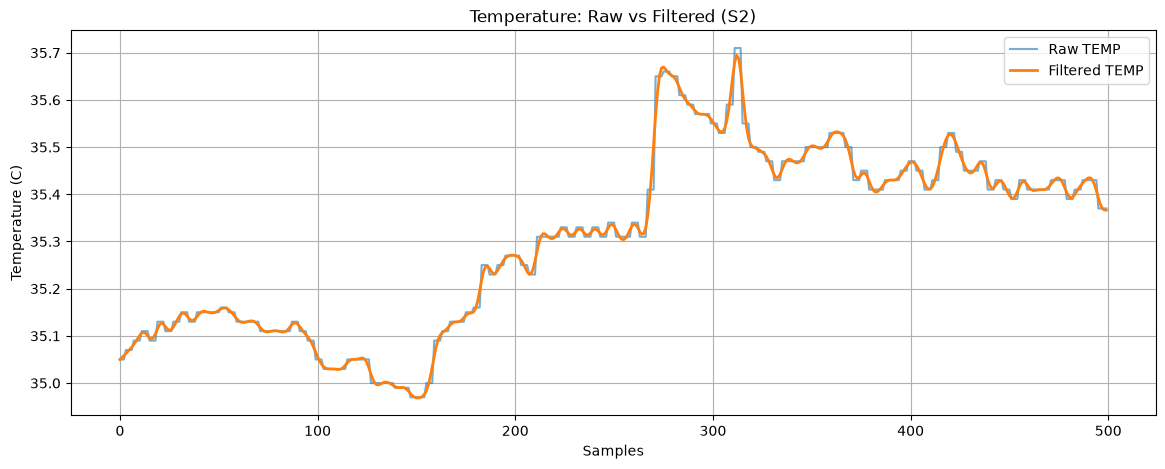

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\TEMP\S2_zoomed.png


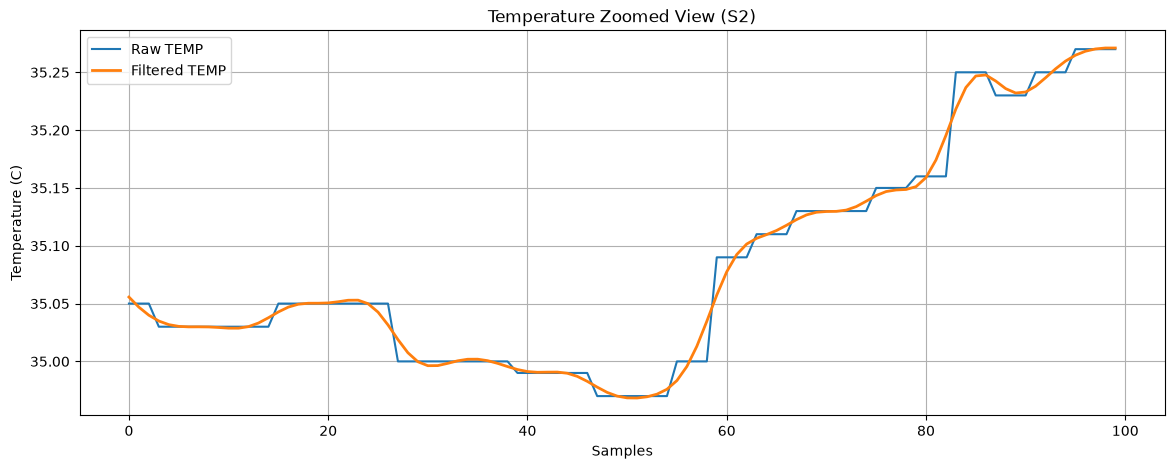

In [29]:
# 05 TEMPERATURE - E4
temp, fs_temp = dl.load_e4_signal(SUBJECT, "TEMP")
temp = temp[5:]  # remove initial noise

def lowpass_filter(sig, cutoff=0.5, fs=4, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype="low")
    return filtfilt(b, a, sig)

filtered_temp = lowpass_filter(temp, fs=fs_temp)

def get_metrics(sig):
    return {
        "Mean": np.mean(sig), "Std": np.std(sig), "Min": np.min(sig), "Max": np.max(sig),
        "Range": np.max(sig) - np.min(sig), "Noise": np.std(np.diff(sig)),
        "Drift": linregress(np.arange(len(sig)), sig).slope,
    }

raw_metrics = get_metrics(temp)
filt_metrics = get_metrics(filtered_temp)

print("\n===== TEMPERATURE METRICS =====\n")
for k in raw_metrics:
    print(f"{k:<10} | Raw: {raw_metrics[k]:.6f} | Filtered: {filt_metrics[k]:.6f}")

print("\n===== PERCENT CHANGE =====\n")
for k in raw_metrics:
    if raw_metrics[k] != 0:
        change = ((filt_metrics[k] - raw_metrics[k]) / raw_metrics[k]) * 100
        print(f"{k:<10}: {change:.2f}%")

# --- Plot: raw vs filtered ---
plt.figure(figsize=(14, 5))
plt.plot(temp[:500], label="Raw TEMP", alpha=0.6)
plt.plot(filtered_temp[:500], label="Filtered TEMP", linewidth=2)
plt.title(f"Temperature: Raw vs Filtered ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid()
save_and_show(f"E4/TEMP/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: zoomed ---
plt.figure(figsize=(14, 5))
plt.plot(temp[100:200], label="Raw TEMP")
plt.plot(filtered_temp[100:200], label="Filtered TEMP", linewidth=2)
plt.title(f"Temperature Zoomed View ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid()
save_and_show(f"E4/TEMP/{SUBJECT}_zoomed.png")


Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\ACC\S2_axes_raw_vs_filtered.png


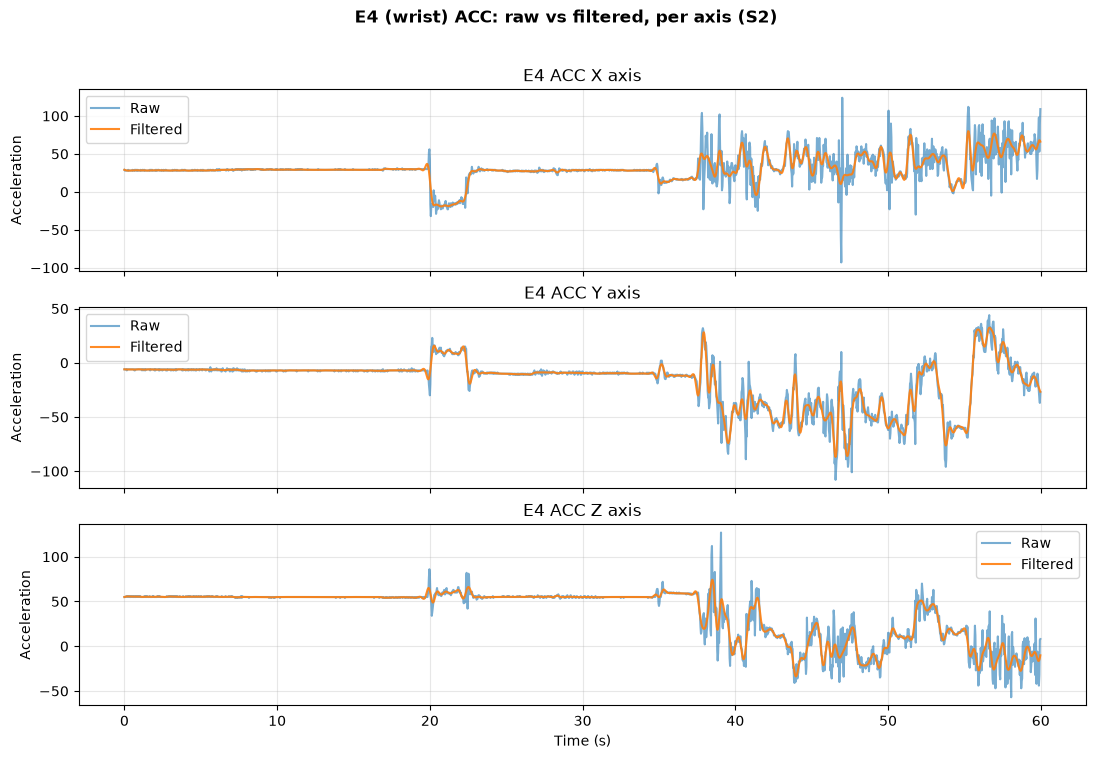

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\E4\ACC\S2_magnitude_raw_vs_filtered.png


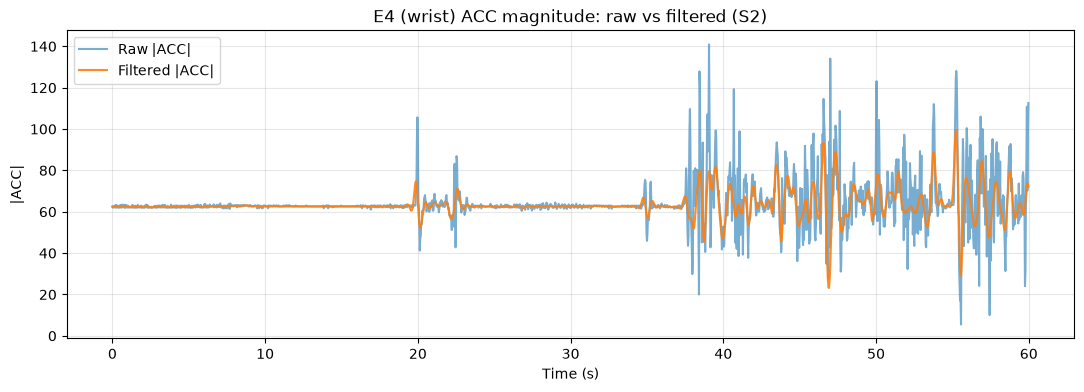

  Axis  Raw Mean  Raw Std  Raw Noise  Raw Range  Filtered Mean  Filtered Std  \
0    X   37.8996  19.2771     5.8760   255.0000        37.8996       18.5735   
1    Y   -9.4579  35.9853     2.7165   232.0000        -9.4579       35.8694   
2    Z   17.3514  23.5762     4.2446   255.0000        17.3514       23.2540   

   Filtered Noise  Filtered Range  
0          0.9183        162.3100  
1          0.7771        170.2643  
2          0.9436        178.7076  

Noise reduction (magnitude): 43.72%


In [30]:
# 06 ACC - EMPATICA (wrist) -- filtering + plotting
acc_e4, fs_acc_e4 = dl.load_e4_acc(SUBJECT)   # shape (n, 3): x, y, z

def lowpass_axes(values, fs, cutoff, order=4):
    sos = butter(order, cutoff / (fs / 2), btype="low", output="sos")
    return sosfiltfilt(sos, values, axis=0)

ACC_E4_CUTOFF = 2.0  # Hz, matches wrist ACC cutoff used elsewhere in the pipeline
acc_e4_filtered = lowpass_axes(acc_e4, fs_acc_e4, ACC_E4_CUTOFF)
magnitude_raw = np.linalg.norm(acc_e4, axis=1)
magnitude_filtered = np.linalg.norm(acc_e4_filtered, axis=1)

# --- Plot: per-axis raw vs filtered ---
samples = min(len(acc_e4), int(fs_acc_e4 * 60))
t = np.arange(samples) / fs_acc_e4
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for axis, label in enumerate(("X", "Y", "Z")):
    axes[axis].plot(t, acc_e4[:samples, axis], label="Raw", alpha=0.6)
    axes[axis].plot(t, acc_e4_filtered[:samples, axis], label="Filtered", alpha=0.9)
    axes[axis].set_title(f"E4 ACC {label} axis")
    axes[axis].set_ylabel("Acceleration")
    axes[axis].grid(alpha=0.3)
    axes[axis].legend()
axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"E4 (wrist) ACC: raw vs filtered, per axis ({SUBJECT})", fontweight="bold")
save_and_show(f"E4/ACC/{SUBJECT}_axes_raw_vs_filtered.png")

# --- Plot: magnitude raw vs filtered ---
plt.figure(figsize=(13, 4))
plt.plot(t, magnitude_raw[:samples], label="Raw |ACC|", alpha=0.6)
plt.plot(t, magnitude_filtered[:samples], label="Filtered |ACC|", alpha=0.9)
plt.title(f"E4 (wrist) ACC magnitude: raw vs filtered ({SUBJECT})")
plt.xlabel("Time (s)")
plt.ylabel("|ACC|")
plt.legend()
plt.grid(alpha=0.3)
save_and_show(f"E4/ACC/{SUBJECT}_magnitude_raw_vs_filtered.png")

# --- Quality metrics ---
def get_axis_metrics(values):
    return {
        "Mean": values.mean(), "Std": values.std(),
        "Noise": np.std(np.diff(values)),
        "Range": np.ptp(values),
    }

rows = []
for axis, label in enumerate(("X", "Y", "Z")):
    raw_m = get_axis_metrics(acc_e4[:, axis])
    filt_m = get_axis_metrics(acc_e4_filtered[:, axis])
    rows.append({"Axis": label, **{f"Raw {k}": v for k, v in raw_m.items()},
                  **{f"Filtered {k}": v for k, v in filt_m.items()}})
print(pd.DataFrame(rows))
print("\nNoise reduction (magnitude):",
      f"{100 * (1 - magnitude_filtered.std() / magnitude_raw.std()):.2f}%")


## RESPIBAN (chest)

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ECG\S2_raw_zoom.png


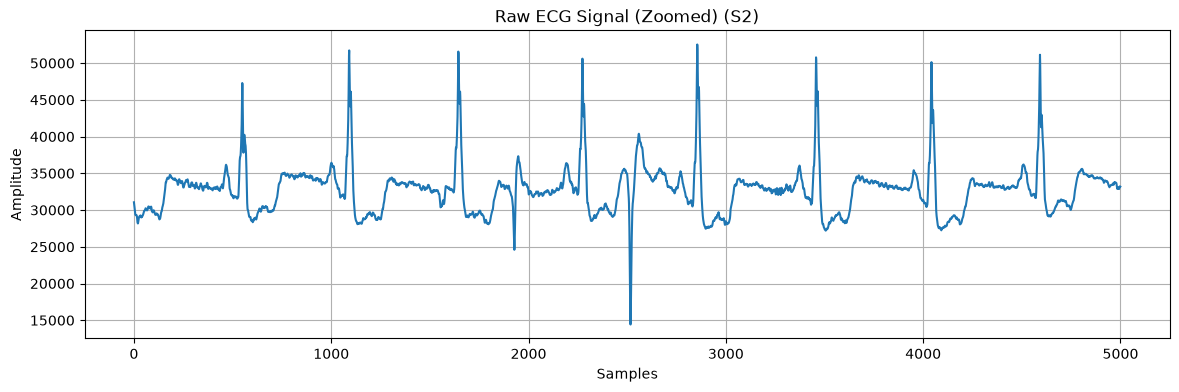

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ECG\S2_filtered_zoom.png


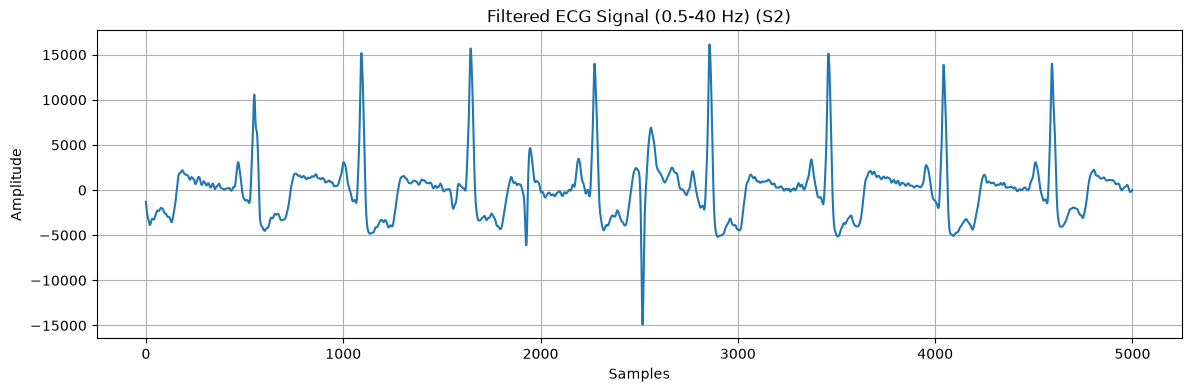

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ECG\S2_raw_vs_filtered.png


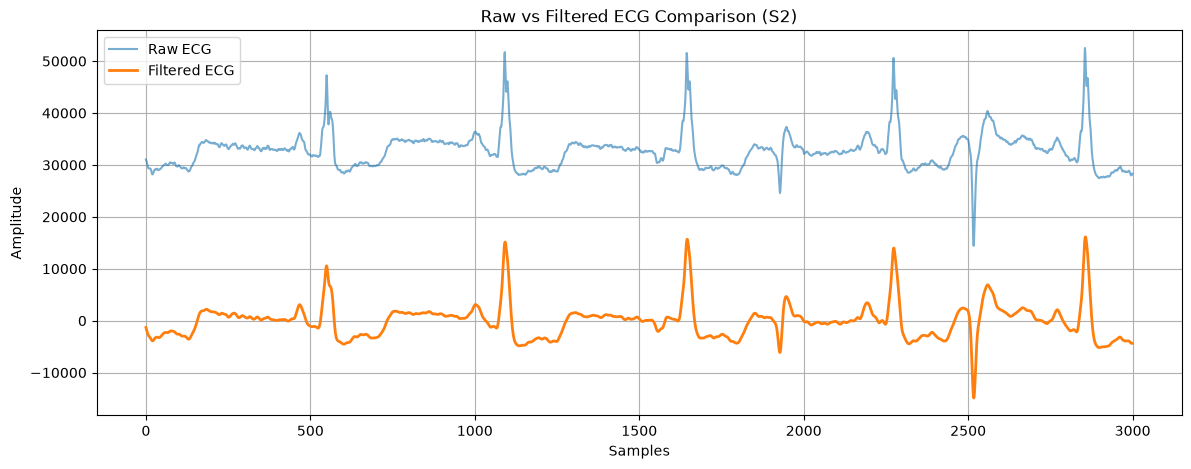

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ECG\S2_dc_removed_vs_filtered.png


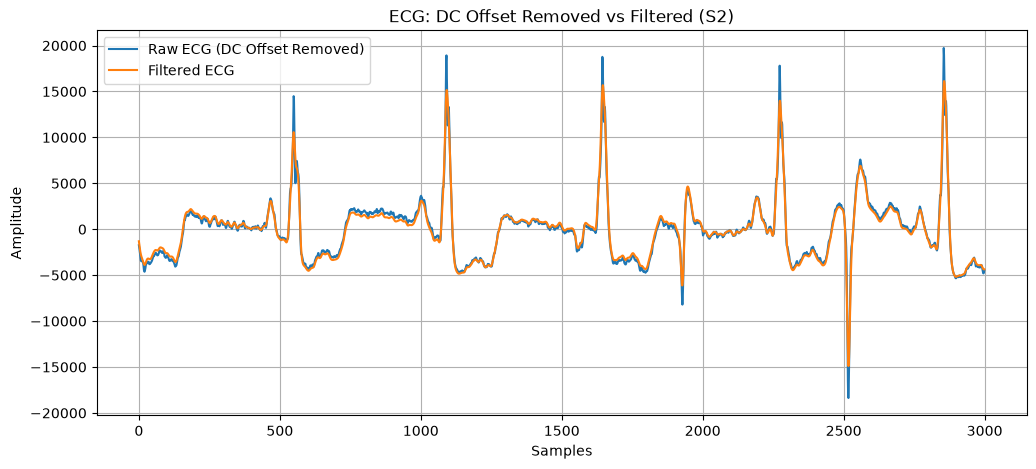

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ECG\S2_zoomed.png


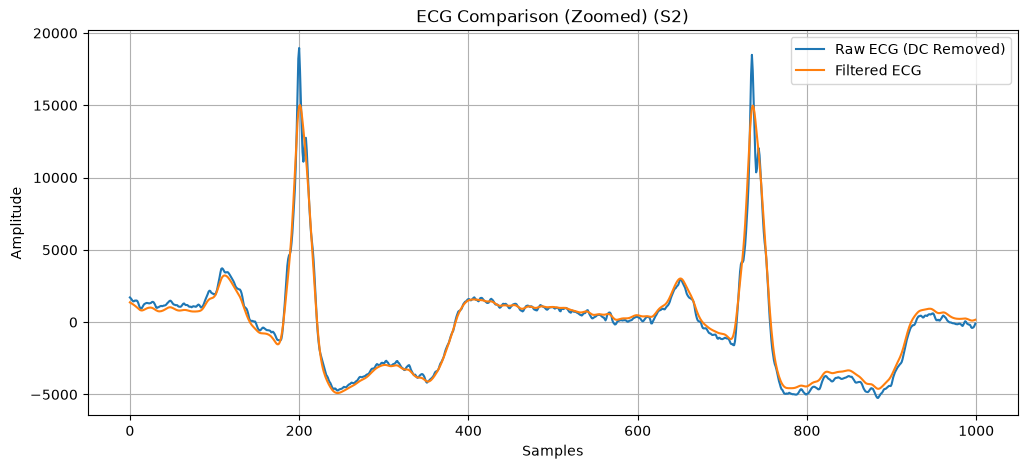

                  Metric         Raw    Filtered  DC Offset Removed
0                   Mean  32794.4800     -0.0428             0.0000
1                    Std   3381.4551   3284.1878          3381.4551
2         Noise Estimate    345.3387    221.8395           345.3387
3         Baseline Drift    379.4841     32.3107            55.4210
4       Outliers (>3std) 107043.0000 114692.0000        107043.0000
5           R Peak Count   7726.0000   7716.0000          7726.0000
6   Mean RR Interval (s)      0.8214      0.8224             0.8214
7    RR Interval Std (s)      0.1166      0.1153             0.1166
8  Mean Heart Rate (BPM)     74.9329     74.7643            74.9329
9   Heart Rate Std (BPM)     13.8716     13.4846            13.8716


In [31]:
# 01 ECG - RESPIBAN
ecg = dl.load_respiban_signal(SUBJECT, "ecg")
fs = 700

def bandpass_filter(sig, fs=700, low=0.5, high=40, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, sig)

ecg_filtered = bandpass_filter(ecg, fs=fs)
ecg_centered = ecg - np.mean(ecg)

# --- Plot: raw zoomed ---
plt.figure(figsize=(14, 4))
plt.plot(ecg[:5000])
plt.title(f"Raw ECG Signal (Zoomed) ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
save_and_show(f"RespiBAN/ECG/{SUBJECT}_raw_zoom.png")

# --- Plot: filtered zoomed ---
plt.figure(figsize=(14, 4))
plt.plot(ecg_filtered[:5000])
plt.title(f"Filtered ECG Signal (0.5-40 Hz) ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
save_and_show(f"RespiBAN/ECG/{SUBJECT}_filtered_zoom.png")

# --- Plot: comparison ---
plt.figure(figsize=(14, 5))
plt.plot(ecg[:3000], label="Raw ECG", alpha=0.6)
plt.plot(ecg_filtered[:3000], label="Filtered ECG", linewidth=2)
plt.title(f"Raw vs Filtered ECG Comparison ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
save_and_show(f"RespiBAN/ECG/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: DC-removed vs filtered ---
n_samples = 3000
plt.figure(figsize=(12, 5))
plt.plot(ecg_centered[:n_samples], label="Raw ECG (DC Offset Removed)")
plt.plot(ecg_filtered[:n_samples], label="Filtered ECG")
plt.title(f"ECG: DC Offset Removed vs Filtered ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/ECG/{SUBJECT}_dc_removed_vs_filtered.png")

# --- Plot: zoomed comparison ---
start, n_samples = 10000, 1000
plt.figure(figsize=(12, 5))
plt.plot(ecg_centered[start:start + n_samples], label="Raw ECG (DC Removed)")
plt.plot(ecg_filtered[start:start + n_samples], label="Filtered ECG")
plt.title(f"ECG Comparison (Zoomed) ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/ECG/{SUBJECT}_zoomed.png")

# --- Quality metrics / R-peak / HR ---
ecg_mean_raw, ecg_mean_filtered, ecg_mean_centered = np.mean(ecg), np.mean(ecg_filtered), np.mean(ecg_centered)
ecg_std_raw, ecg_std_filtered, ecg_std_centered = np.std(ecg), np.std(ecg_filtered), np.std(ecg_centered)
ecg_noise_raw = np.std(np.diff(ecg))
ecg_noise_filtered = np.std(np.diff(ecg_filtered))
ecg_noise_centered = np.std(np.diff(ecg_centered))

window = 7000
ecg_drift_raw = np.std(np.convolve(ecg, np.ones(window) / window, mode="same"))
ecg_drift_filtered = np.std(np.convolve(ecg_filtered, np.ones(window) / window, mode="same"))
ecg_drift_centered = np.std(np.convolve(ecg_centered, np.ones(window) / window, mode="same"))

z_raw = np.abs((ecg - ecg_mean_raw) / ecg_std_raw)
z_filtered = np.abs((ecg_filtered - ecg_mean_filtered) / ecg_std_filtered)
z_centered = np.abs((ecg_centered - ecg_mean_centered) / ecg_std_centered)
outliers_raw, outliers_filtered, outliers_centered = np.sum(z_raw > 3), np.sum(z_filtered > 3), np.sum(z_centered > 3)

peaks_raw, _ = find_peaks(ecg_centered, distance=0.4 * fs, prominence=np.std(ecg_centered))
peaks_filtered, _ = find_peaks(ecg_filtered, distance=0.4 * fs, prominence=np.std(ecg_filtered))

rr_raw = np.diff(peaks_raw) / fs
rr_filtered = np.diff(peaks_filtered) / fs
hr_raw = 60 / rr_raw
hr_filtered = 60 / rr_filtered

results = pd.DataFrame({
    "Metric": ["Mean", "Std", "Noise Estimate", "Baseline Drift", "Outliers (>3std)",
               "R Peak Count", "Mean RR Interval (s)", "RR Interval Std (s)",
               "Mean Heart Rate (BPM)", "Heart Rate Std (BPM)"],
    "Raw": [ecg_mean_raw, ecg_std_raw, ecg_noise_raw, ecg_drift_raw, outliers_raw,
            len(peaks_raw), np.mean(rr_raw), np.std(rr_raw), np.mean(hr_raw), np.std(hr_raw)],
    "Filtered": [ecg_mean_filtered, ecg_std_filtered, ecg_noise_filtered, ecg_drift_filtered, outliers_filtered,
                 len(peaks_filtered), np.mean(rr_filtered), np.std(rr_filtered), np.mean(hr_filtered), np.std(hr_filtered)],
    "DC Offset Removed": [ecg_mean_centered, ecg_std_centered, ecg_noise_centered, ecg_drift_centered, outliers_centered,
                           len(peaks_raw), np.mean(rr_raw), np.std(rr_raw), np.mean(hr_raw), np.std(hr_raw)],
})
print(results)


Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\EDA\S2_filtered.png


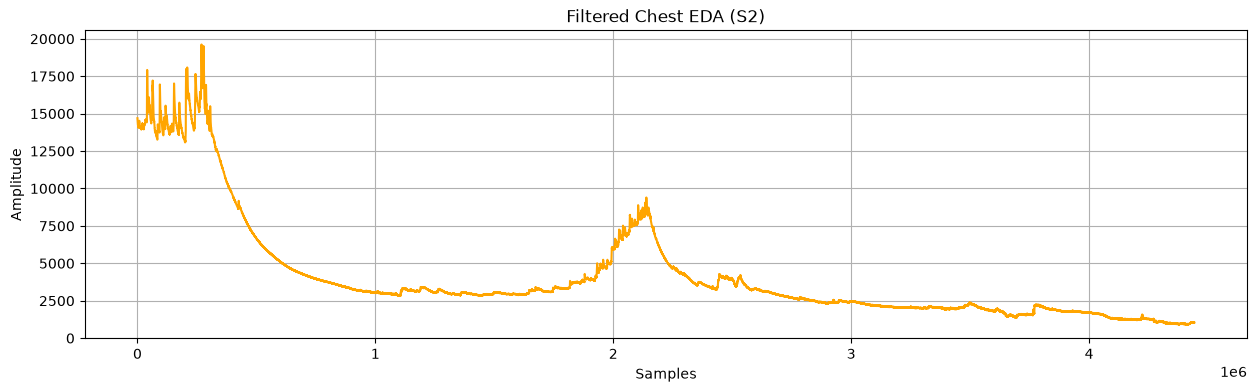

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\EDA\S2_raw_vs_filtered.png


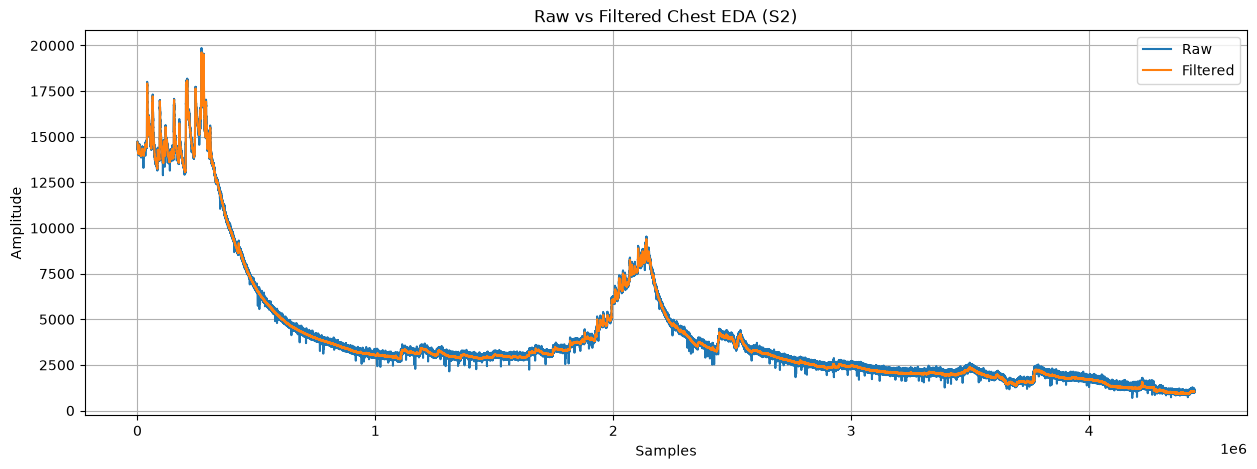

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\EDA\S2_zoomed.png


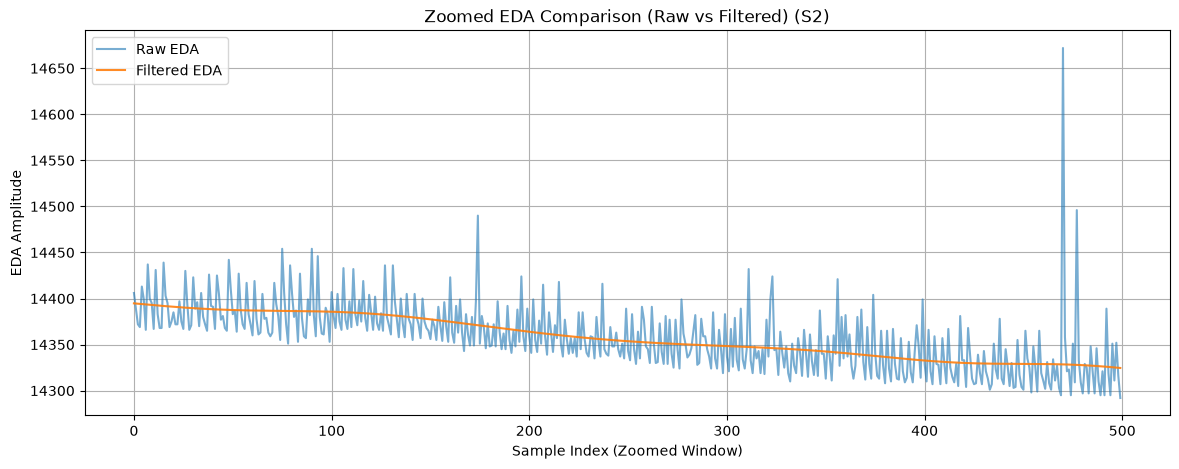

              Metric     Raw EDA  Filtered EDA  % Change
0               Mean   4160.4218     4160.4218   -0.0000
1                Std   3548.2578     3547.9308   -0.0092
2     Noise Estimate     67.9711        0.2317  -99.6592
3     Baseline Drift   1111.4218     1116.2164    0.4314
4   Outliers (>3std) 120285.0000   120323.0000    0.0316
5          SCR Peaks 778297.0000    22037.0000  -97.1686
6  Slope Variability     67.9711        0.2317  -99.6592


In [32]:
# 02 EDA - RESPIBAN
EDA = dl.load_respiban_signal(SUBJECT, "eda")
fs = 700
cutoff, order = 5, 4
b, a = butter(order, cutoff / (fs / 2), btype="low")
EDA_filtered = filtfilt(b, a, EDA)

# --- Plot: filtered only ---
plt.figure(figsize=(15, 4))
plt.plot(EDA_filtered, color="orange")
plt.title(f"Filtered Chest EDA ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
save_and_show(f"RespiBAN/EDA/{SUBJECT}_filtered.png")

# --- Plot: raw vs filtered ---
plt.figure(figsize=(15, 5))
plt.plot(EDA, label="Raw")
plt.plot(EDA_filtered, label="Filtered")
plt.title(f"Raw vs Filtered Chest EDA ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/EDA/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: zoomed comparison ---
EDA = np.array(EDA)
EDA_filtered = np.array(EDA_filtered)
start, end = 1000, 1500
plt.figure(figsize=(14, 5))
plt.plot(EDA[start:end], label="Raw EDA", alpha=0.6)
plt.plot(EDA_filtered[start:end], label="Filtered EDA", alpha=0.9)
plt.title(f"Zoomed EDA Comparison (Raw vs Filtered) ({SUBJECT})")
plt.xlabel("Sample Index (Zoomed Window)")
plt.ylabel("EDA Amplitude")
plt.legend()
plt.grid()
save_and_show(f"RespiBAN/EDA/{SUBJECT}_zoomed.png")

# --- Metrics ---
def noise_estimate(sig):
    return np.std(np.diff(sig))

def baseline_drift(sig):
    return np.mean(sig) - np.median(sig)

def outlier_count(sig):
    mean, std = np.mean(sig), np.std(sig)
    if std == 0:
        return 0
    return np.sum(np.abs((sig - mean) / std) > 3)

def scr_peaks(sig, fs=4):
    peaks, _ = find_peaks(sig, prominence=0.01, distance=int(fs * 1))
    return len(peaks)

def compute_metrics(sig, fs=4):
    return {
        "Mean": np.mean(sig), "Std": np.std(sig), "Noise Estimate": noise_estimate(sig),
        "Baseline Drift": baseline_drift(sig), "Outliers (>3std)": outlier_count(sig),
        "SCR Peaks": scr_peaks(sig, fs), "Slope Variability": noise_estimate(sig),
    }

raw_metrics = compute_metrics(EDA)
filtered_metrics = compute_metrics(EDA_filtered)

rows = []
for key in raw_metrics:
    raw_val, filt_val = raw_metrics[key], filtered_metrics[key]
    pct_change = ((filt_val - raw_val) / raw_val) * 100 if raw_val != 0 else np.nan
    rows.append([key, raw_val, filt_val, pct_change])

df = pd.DataFrame(rows, columns=["Metric", "Raw EDA", "Filtered EDA", "% Change"])
pd.set_option("display.float_format", "{:.4f}".format)
print(df)


Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\EMG\S2_dc_offset_effect.png


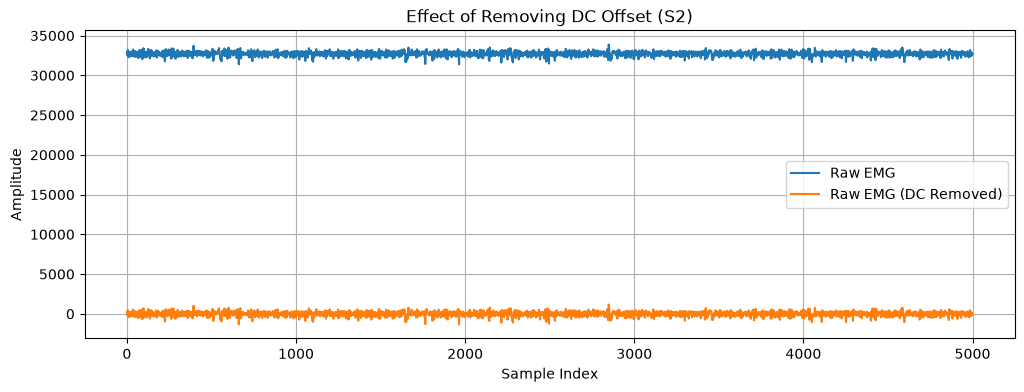

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\EMG\S2_dc_removed_vs_filtered.png


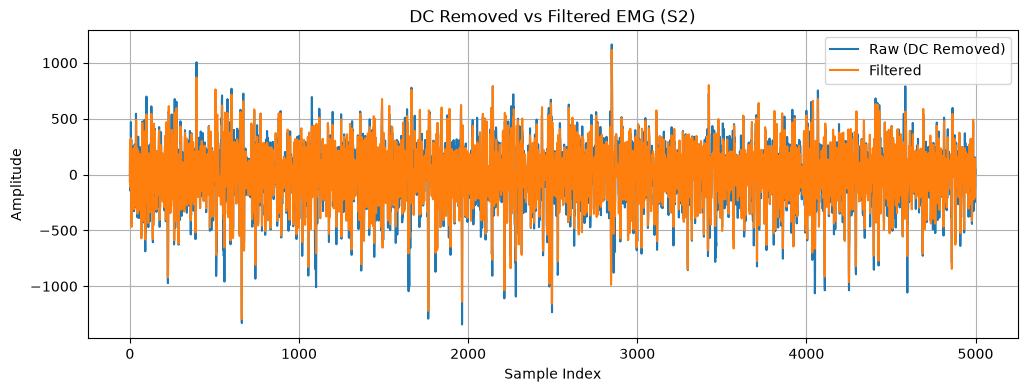

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\EMG\S2_zoomed.png


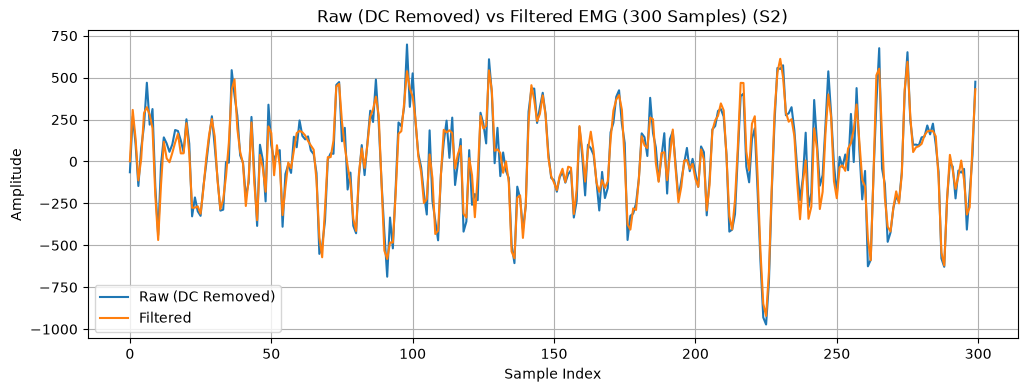

           Metric        Raw   Filtered  Centered (DC offset removed)
0            Mean 32715.2907     0.0003                       -0.0000
1             Std   253.5417   220.3058                      253.5417
2  Spikes (>3std) 68188.0000 62161.0000                    68188.0000
3  Noise Estimate   240.2524   183.3149                      240.2524
4  Drift Estimate   374.6745     0.1024                        4.4989


In [33]:
# 03 EMG - RESPIBAN
emg = dl.load_respiban_signal(SUBJECT, "emg")
fs = 700
lowcut, highcut = 20, 250
b, a = butter(4, [lowcut / (fs / 2), highcut / (fs / 2)], btype="band")
emg_filtered = filtfilt(b, a, emg)
emg_centered = emg - np.mean(emg)

# --- Plot: DC offset effect ---
plt.figure(figsize=(12, 4))
plt.plot(emg[:5000], label="Raw EMG")
plt.plot(emg_centered[:5000], label="Raw EMG (DC Removed)")
plt.title(f"Effect of Removing DC Offset ({SUBJECT})")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/EMG/{SUBJECT}_dc_offset_effect.png")

# --- Plot: DC-removed vs filtered ---
plt.figure(figsize=(12, 4))
plt.plot(emg_centered[:5000], label="Raw (DC Removed)")
plt.plot(emg_filtered[:5000], label="Filtered")
plt.title(f"DC Removed vs Filtered EMG ({SUBJECT})")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/EMG/{SUBJECT}_dc_removed_vs_filtered.png")

# --- Plot: zoomed ---
n_samples = 300
plt.figure(figsize=(12, 4))
plt.plot(emg_centered[:n_samples], label="Raw (DC Removed)", linewidth=1.5)
plt.plot(emg_filtered[:n_samples], label="Filtered", linewidth=1.5)
plt.title(f"Raw (DC Removed) vs Filtered EMG ({n_samples} Samples) ({SUBJECT})")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/EMG/{SUBJECT}_zoomed.png")

# --- Quality metrics ---
emg_mean_raw, emg_mean_filtered, emg_mean_centered = np.mean(emg), np.mean(emg_filtered), np.mean(emg_centered)
emg_std_raw, emg_std_filtered, emg_std_centered = np.std(emg), np.std(emg_filtered), np.std(emg_centered)

emg_z_raw = np.abs((emg - emg_mean_raw) / emg_std_raw)
emg_z_filtered = np.abs((emg_filtered - emg_mean_filtered) / emg_std_filtered)
emg_z_centered = np.abs((emg_centered - emg_mean_centered) / emg_std_centered)
emg_spikes_raw, emg_spikes_filtered, emg_spikes_centered = np.sum(emg_z_raw > 3), np.sum(emg_z_filtered > 3), np.sum(emg_z_centered > 3)

emg_noise_raw = np.std(np.diff(emg))
emg_noise_filtered = np.std(np.diff(emg_filtered))
emg_noise_centered = np.std(np.diff(emg_centered))

window = 7000
emg_drift_raw = np.std(np.convolve(emg, np.ones(window) / window, mode="same"))
emg_drift_filtered = np.std(np.convolve(emg_filtered, np.ones(window) / window, mode="same"))
emg_drift_centered = np.std(np.convolve(emg_centered, np.ones(window) / window, mode="same"))

results = pd.DataFrame({
    "Metric": ["Mean", "Std", "Spikes (>3std)", "Noise Estimate", "Drift Estimate"],
    "Raw": [emg_mean_raw, emg_std_raw, emg_spikes_raw, emg_noise_raw, emg_drift_raw],
    "Filtered": [emg_mean_filtered, emg_std_filtered, emg_spikes_filtered, emg_noise_filtered, emg_drift_filtered],
    "Centered (DC offset removed)": [emg_mean_centered, emg_std_centered, emg_spikes_centered, emg_noise_centered, emg_drift_centered],
})
print(results)


Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\RESP\S2_raw_vs_filtered.png


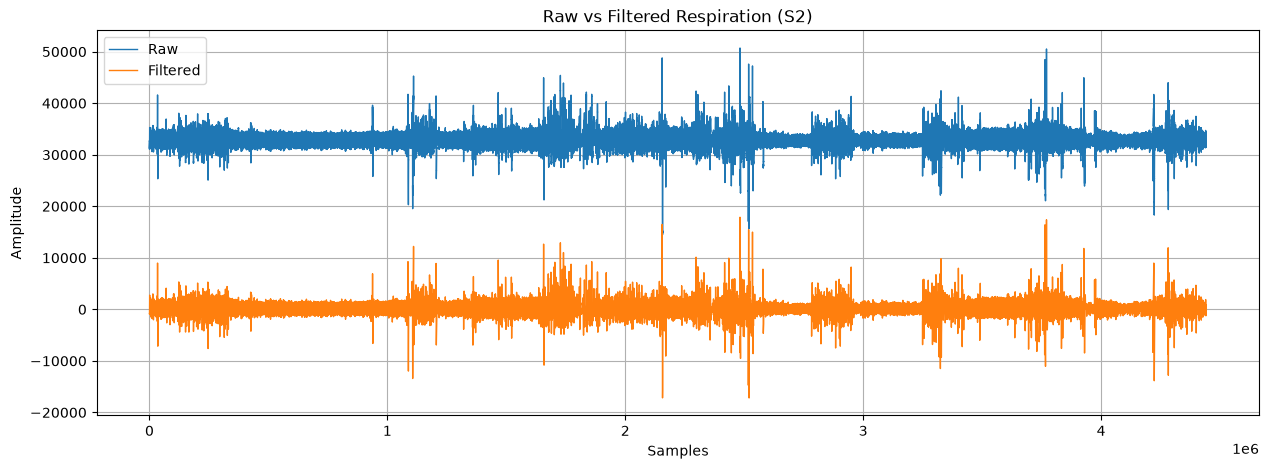

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\RESP\S2_first_3000.png


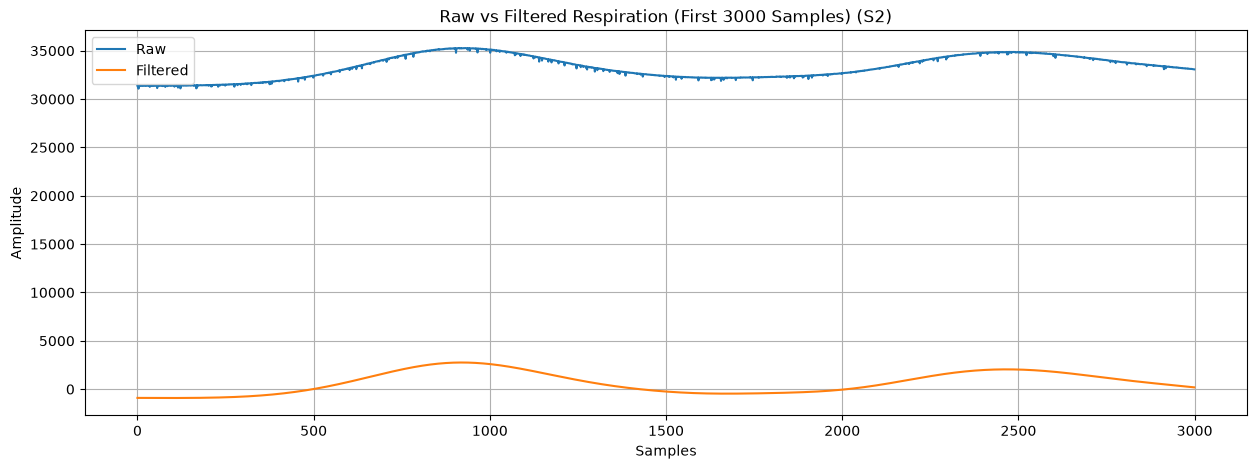

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\RESP\S2_first_20s_raw.png


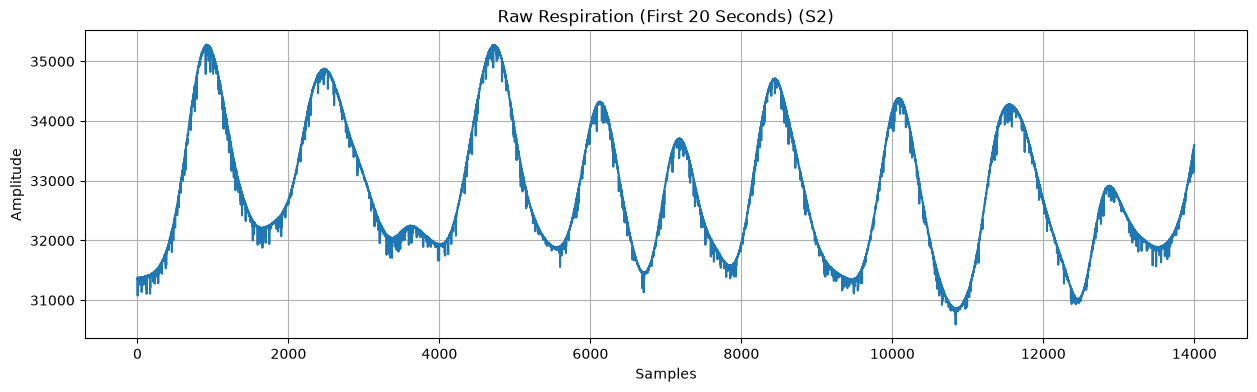

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\RESP\S2_dc_removed_vs_filtered.png


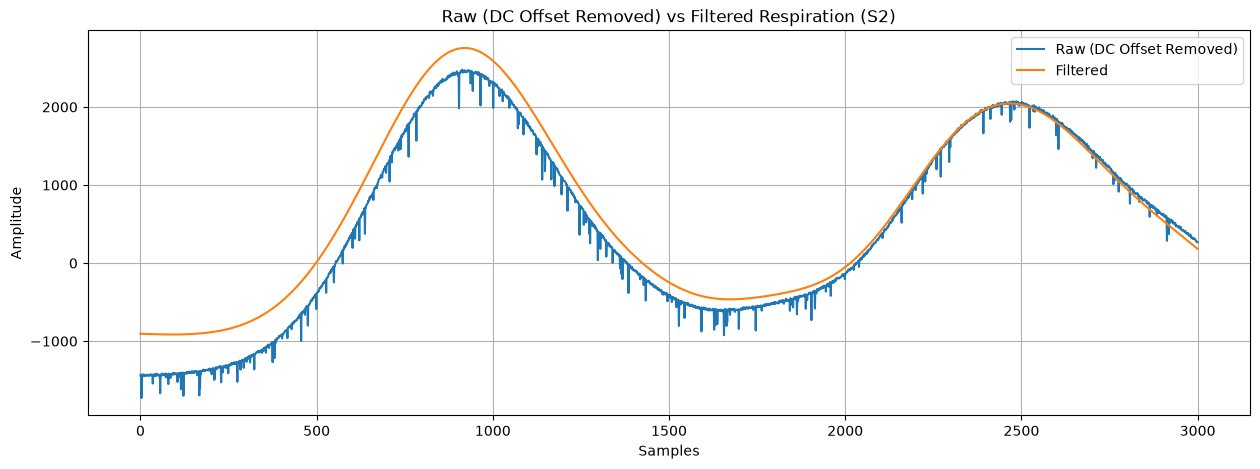

                         Metric  DC Offset Removed   Filtered
0                          Mean             0.0000     0.2886
1                           Std          1897.7539  1871.7863
2                Noise Estimate            66.8844     5.1453
3                Baseline Drift           332.9169   265.6338
4              Outliers (>3std)         75219.0000 73749.0000
5                  Breath Count          2172.0000  2144.0000
6      Mean Breath Interval (s)             2.9221     2.9603
7       Breath Interval Std (s)             0.8781     0.9445
8  Breathing Rate (breaths/min)            20.5364    20.2716


In [34]:
# 04 Respiration - RESPIBAN
RESPIRATION = dl.load_respiban_signal(SUBJECT, "resp")
fs = 700
lowcut, highcut = 0.05, 2.0
sos = butter(4, [lowcut / (fs / 2), highcut / (fs / 2)], btype="band", output="sos")
RESPIRATION_filtered = sosfiltfilt(sos, RESPIRATION)

# --- Plot: full raw vs filtered ---
plt.figure(figsize=(15, 5))
plt.plot(RESPIRATION, label="Raw", linewidth=1)
plt.plot(RESPIRATION_filtered, label="Filtered", linewidth=1)
plt.title(f"Raw vs Filtered Respiration ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/RESP/{SUBJECT}_raw_vs_filtered.png")

# --- Plot: first 3000 samples ---
samples = 3000
plt.figure(figsize=(15, 5))
plt.plot(RESPIRATION[:samples], label="Raw", linewidth=1.5)
plt.plot(RESPIRATION_filtered[:samples], label="Filtered", linewidth=1.5)
plt.title(f"Raw vs Filtered Respiration (First 3000 Samples) ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/RESP/{SUBJECT}_first_3000.png")

# --- Plot: first 20 seconds, raw only ---
seconds = 20
samples = seconds * fs
plt.figure(figsize=(15, 4))
plt.plot(RESPIRATION[:samples])
plt.title(f"Raw Respiration (First 20 Seconds) ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
save_and_show(f"RespiBAN/RESP/{SUBJECT}_first_20s_raw.png")

# --- Plot: DC-removed vs filtered ---
RESPIRATION_centered = RESPIRATION - np.mean(RESPIRATION)
samples = 3000
plt.figure(figsize=(15, 5))
plt.plot(RESPIRATION_centered[:samples], label="Raw (DC Offset Removed)", linewidth=1.5)
plt.plot(RESPIRATION_filtered[:samples], label="Filtered", linewidth=1.5)
plt.title(f"Raw (DC Offset Removed) vs Filtered Respiration ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
save_and_show(f"RespiBAN/RESP/{SUBJECT}_dc_removed_vs_filtered.png")

# --- Quality metrics ---
mean_centered, mean_filtered = np.mean(RESPIRATION_centered), np.mean(RESPIRATION_filtered)
std_centered, std_filtered = np.std(RESPIRATION_centered), np.std(RESPIRATION_filtered)
noise_centered = np.std(np.diff(RESPIRATION_centered))
noise_filtered = np.std(np.diff(RESPIRATION_filtered))

window = 7000
drift_centered = np.std(np.convolve(RESPIRATION_centered, np.ones(window) / window, mode="same"))
drift_filtered = np.std(np.convolve(RESPIRATION_filtered, np.ones(window) / window, mode="same"))

z_centered = np.abs((RESPIRATION_centered - mean_centered) / std_centered)
z_filtered = np.abs((RESPIRATION_filtered - mean_filtered) / std_filtered)
outliers_centered, outliers_filtered = np.sum(z_centered > 3), np.sum(z_filtered > 3)

peaks_centered, _ = find_peaks(RESPIRATION_centered, distance=fs * 1.5, prominence=0.3 * std_centered)
peaks_filtered, _ = find_peaks(RESPIRATION_filtered, distance=fs * 1.5, prominence=0.3 * std_filtered)
interval_centered = np.diff(peaks_centered) / fs
interval_filtered = np.diff(peaks_filtered) / fs

duration = len(RESPIRATION) / fs
breathing_rate_centered = len(peaks_centered) / (duration / 60)
breathing_rate_filtered = len(peaks_filtered) / (duration / 60)

results = pd.DataFrame({
    "Metric": ["Mean", "Std", "Noise Estimate", "Baseline Drift", "Outliers (>3std)",
               "Breath Count", "Mean Breath Interval (s)", "Breath Interval Std (s)", "Breathing Rate (breaths/min)"],
    "DC Offset Removed": [mean_centered, std_centered, noise_centered, drift_centered, outliers_centered,
                           len(peaks_centered), np.mean(interval_centered), np.std(interval_centered), breathing_rate_centered],
    "Filtered": [mean_filtered, std_filtered, noise_filtered, drift_filtered, outliers_filtered,
                 len(peaks_filtered), np.mean(interval_filtered), np.std(interval_filtered), breathing_rate_filtered],
})
print(results)


      Metric      Raw  Filtered  % Change
0       Mean   0.0000   -0.0000  -20.2973
1        Std 869.0489  869.0004   -0.0056
2      Noise  19.2676    9.3680  -51.3796
3      Drift 290.4592  290.9478    0.1682
4   Outliers   0.0000    0.0000    0.0000
5  Slope Var  19.2676    9.3680  -51.3796
Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\TEMP\S2_raw_vs_filtered_zoom.png


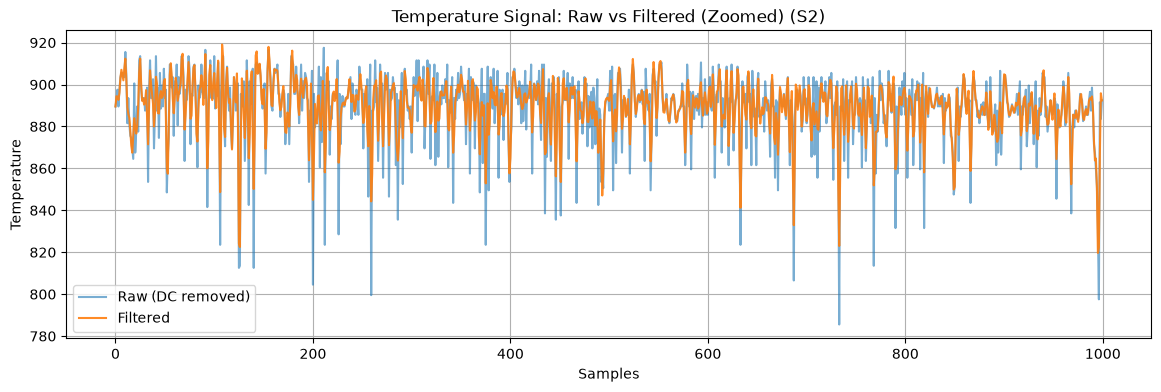

In [35]:
# 05 Temperature - RESPIBAN
temp_raw = dl.load_respiban_signal(SUBJECT, "temp")
temp_dc = temp_raw - np.mean(temp_raw)

def lowpass(sig, fs=1, cutoff=0.3):
    nyq = 0.5 * fs
    b, a = butter(3, cutoff / nyq, btype="low")
    return filtfilt(b, a, sig)

temperature_filtered = lowpass(temp_dc, fs=1, cutoff=0.3)

def metrics(x):
    return {
        "Mean": np.mean(x), "Std": np.std(x), "Noise": np.std(np.diff(x)),
        "Drift": np.mean(x) - np.median(x),
        "Outliers": np.sum(np.abs((x - np.mean(x)) / (np.std(x) + 1e-6)) > 3),
        "Slope Var": np.std(np.diff(x)),
    }

raw_m = metrics(temp_dc)
filt_m = metrics(temperature_filtered)

rows = []
for k in raw_m:
    pct = ((filt_m[k] - raw_m[k]) / (raw_m[k] + 1e-6)) * 100
    rows.append([k, raw_m[k], filt_m[k], pct])
temp_table = pd.DataFrame(rows, columns=["Metric", "Raw", "Filtered", "% Change"])
print(temp_table)

# --- Plot: raw vs filtered, zoomed ---
plt.figure(figsize=(14, 4))
plt.plot(temp_dc[:1000], label="Raw (DC removed)", alpha=0.6)
plt.plot(temperature_filtered[:1000], label="Filtered", alpha=0.9)
plt.title(f"Temperature Signal: Raw vs Filtered (Zoomed) ({SUBJECT})")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
save_and_show(f"RespiBAN/TEMP/{SUBJECT}_raw_vs_filtered_zoom.png")


Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ACC\S2_axes_raw_vs_filtered.png


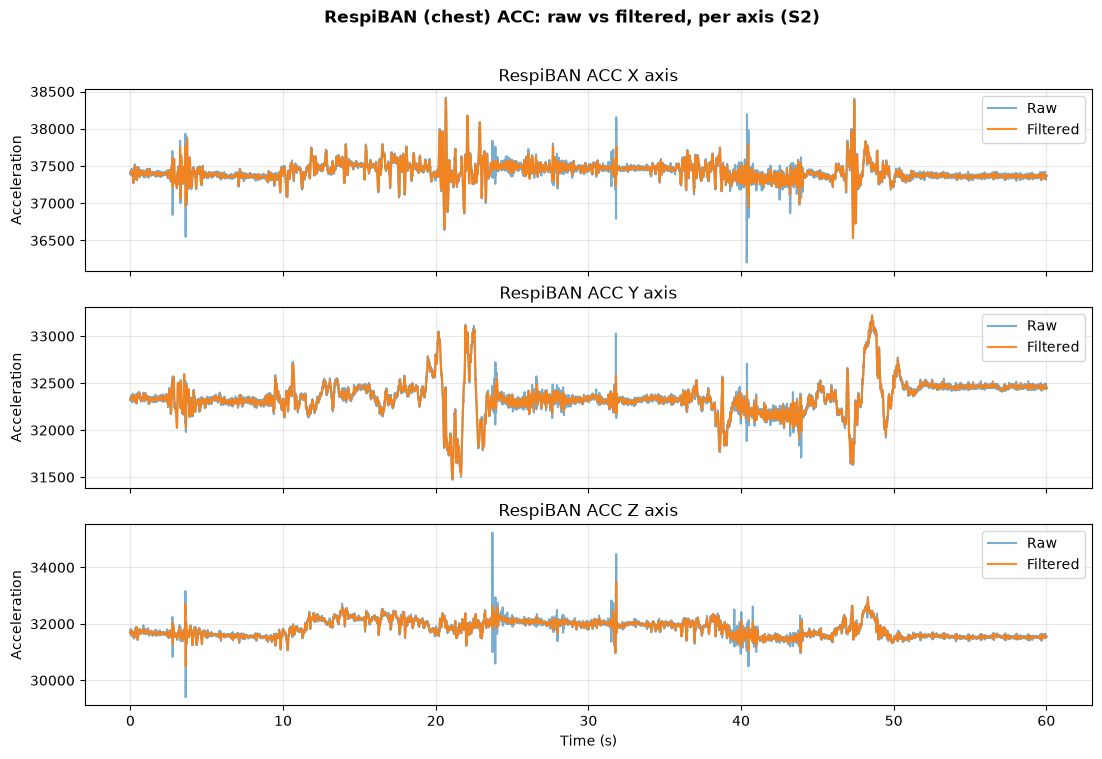

Saved: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output\RespiBAN\ACC\S2_magnitude_raw_vs_filtered.png


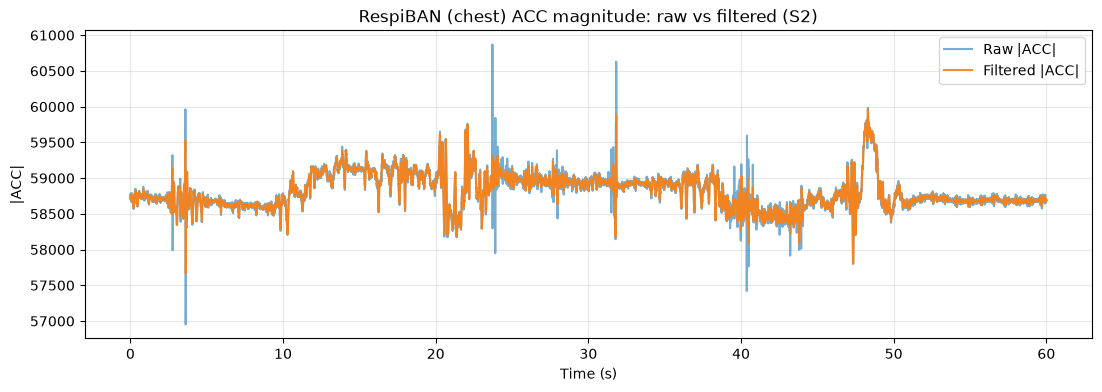

  Axis   Raw Mean   Raw Std  Raw Noise  Raw Range  Filtered Mean  \
0    X 36795.6359  866.3968    10.5164  9074.0000     36795.6359   
1    Y 32333.3972  316.2120     9.2784  5995.0000     32333.3971   
2    Z 30920.1572 1478.9737    17.1304 12054.0000     30920.1573   

   Filtered Std  Filtered Noise  Filtered Range  
0      866.2497          5.3057       8652.2012  
1      315.9805          3.6718       5702.8385  
2     1478.6588          5.8976      10202.9409  

Noise reduction (magnitude): 0.01%


In [36]:
# 06 ACC - RESPIBAN (chest) -- filtering + plotting
acc_rb = dl.load_respiban_signal(SUBJECT, "acc")   # shape (n, 3): x, y, z
fs_acc_rb = 700

ACC_RB_CUTOFF = 20.0  # Hz, matches chest ACC cutoff used elsewhere in the pipeline
sos = butter(4, ACC_RB_CUTOFF / (fs_acc_rb / 2), btype="low", output="sos")
acc_rb_filtered = sosfiltfilt(sos, acc_rb, axis=0)

magnitude_raw = np.linalg.norm(acc_rb, axis=1)
magnitude_filtered = np.linalg.norm(acc_rb_filtered, axis=1)

# --- Plot: per-axis raw vs filtered ---
samples = min(len(acc_rb), int(fs_acc_rb * 60))
t = np.arange(samples) / fs_acc_rb
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for axis, label in enumerate(("X", "Y", "Z")):
    axes[axis].plot(t, acc_rb[:samples, axis], label="Raw", alpha=0.6)
    axes[axis].plot(t, acc_rb_filtered[:samples, axis], label="Filtered", alpha=0.9)
    axes[axis].set_title(f"RespiBAN ACC {label} axis")
    axes[axis].set_ylabel("Acceleration")
    axes[axis].grid(alpha=0.3)
    axes[axis].legend()
axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"RespiBAN (chest) ACC: raw vs filtered, per axis ({SUBJECT})", fontweight="bold")
save_and_show(f"RespiBAN/ACC/{SUBJECT}_axes_raw_vs_filtered.png")

# --- Plot: magnitude raw vs filtered ---
plt.figure(figsize=(13, 4))
plt.plot(t, magnitude_raw[:samples], label="Raw |ACC|", alpha=0.6)
plt.plot(t, magnitude_filtered[:samples], label="Filtered |ACC|", alpha=0.9)
plt.title(f"RespiBAN (chest) ACC magnitude: raw vs filtered ({SUBJECT})")
plt.xlabel("Time (s)")
plt.ylabel("|ACC|")
plt.legend()
plt.grid(alpha=0.3)
save_and_show(f"RespiBAN/ACC/{SUBJECT}_magnitude_raw_vs_filtered.png")

# --- Quality metrics ---
def get_axis_metrics(values):
    return {"Mean": values.mean(), "Std": values.std(), "Noise": np.std(np.diff(values)), "Range": np.ptp(values)}

rows = []
for axis, label in enumerate(("X", "Y", "Z")):
    raw_m = get_axis_metrics(acc_rb[:, axis])
    filt_m = get_axis_metrics(acc_rb_filtered[:, axis])
    rows.append({"Axis": label, **{f"Raw {k}": v for k, v in raw_m.items()},
                  **{f"Filtered {k}": v for k, v in filt_m.items()}})
print(pd.DataFrame(rows))
print("\nNoise reduction (magnitude):",
      f"{100 * (1 - magnitude_filtered.std() / magnitude_raw.std()):.2f}%")


## Save outputs

In [37]:
# Save all filtered signals to CSV
FILTERED_DIR = PREPROCESSED_ROOT / "filtered"

pd.DataFrame({"EDA": eda_filtered}).to_csv(FILTERED_DIR / "eda_filtered.csv", index=False)
pd.DataFrame({"BVP": bvp_filtered}).to_csv(FILTERED_DIR / "bvp_filtered.csv", index=False)
pd.DataFrame({"HR": hr_filtered}).to_csv(FILTERED_DIR / "hr_filtered.csv", index=False)
pd.DataFrame({"TEMP": filtered_temp}).to_csv(FILTERED_DIR / "temp_filtered.csv", index=False)
pd.DataFrame({"IBI": ibi_filtered}).to_csv(FILTERED_DIR / "ibi_filtered.csv", index=False)
pd.DataFrame(acc_e4_filtered, columns=["x", "y", "z"]).to_csv(FILTERED_DIR / "acc_filtered.csv", index=False)

pd.DataFrame({"ECG": ecg_filtered}).to_csv(FILTERED_DIR / "ecg_filtered_respiban.csv", index=False)
pd.DataFrame({"EDA": EDA_filtered}).to_csv(FILTERED_DIR / "eda_filtered_respiban.csv", index=False)
pd.DataFrame({"EMG": emg_centered}).to_csv(FILTERED_DIR / "emg_centered_respiban.csv", index=False)
pd.DataFrame({"RESP": RESPIRATION_filtered}).to_csv(FILTERED_DIR / "resp_filtered_respiban.csv", index=False)
pd.DataFrame({"TEMP": temperature_filtered}).to_csv(FILTERED_DIR / "temp_filtered_respiban.csv", index=False)
pd.DataFrame(acc_rb_filtered, columns=["x", "y", "z"]).to_csv(FILTERED_DIR / "acc_filtered_respiban.csv", index=False)

print(f"Saved filtered signals to {FILTERED_DIR}")


Saved filtered signals to ..\Data\preprocessed_data\filtered


In [38]:
# Verify output structure (files were saved directly to their target folders,
# so no post-hoc file-moving is needed anymore)
import os

print("Preprocessed data:")
for root, dirs, files in os.walk(PREPROCESSED_ROOT):
    for f in files:
        print(" ", Path(root) / f)

print("\nPlots:")
for root, dirs, files in os.walk(PLOTS_ROOT):
    for f in files:
        print(" ", Path(root) / f)


Preprocessed data:
  ..\Data\preprocessed_data\filtered\acc_filtered.csv
  ..\Data\preprocessed_data\filtered\acc_filtered_respiban.csv
  ..\Data\preprocessed_data\filtered\bvp_filtered.csv
  ..\Data\preprocessed_data\filtered\ecg_filtered_respiban.csv
  ..\Data\preprocessed_data\filtered\eda_filtered.csv
  ..\Data\preprocessed_data\filtered\eda_filtered_respiban.csv
  ..\Data\preprocessed_data\filtered\emg_centered_respiban.csv
  ..\Data\preprocessed_data\filtered\hr_filtered.csv
  ..\Data\preprocessed_data\filtered\ibi_filtered.csv
  ..\Data\preprocessed_data\filtered\resp_filtered_respiban.csv
  ..\Data\preprocessed_data\filtered\temp_filtered.csv
  ..\Data\preprocessed_data\filtered\temp_filtered_respiban.csv

Plots:
  output\E4\ACC\S2_axes_raw_vs_filtered.png
  output\E4\ACC\S2_magnitude_raw_vs_filtered.png
  output\E4\BVP\S2_filtered_zoom.png
  output\E4\BVP\S2_raw_vs_filtered.png
  output\E4\EDA\S2_filtered.png
  output\E4\EDA\S2_raw_vs_filtered.png
  output\E4\EDA\S2_raw_vs_fil

In [39]:
# Save all plots into an "output" folder inside 01_filtering/, instead of Data/Plots
PLOTS_ROOT = Path("output")
for folder in PLOT_FOLDERS:
    (PLOTS_ROOT / folder).mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved under: {PLOTS_ROOT.resolve()}")

Plots will be saved under: C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output


In [40]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()   # C:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering
PLOTS_ROOT = NOTEBOOK_DIR / "output"
for folder in PLOT_FOLDERS:
    (PLOTS_ROOT / folder).mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved under: {PLOTS_ROOT}")

Plots will be saved under: c:\Users\abhishek\Desktop\Stress Detection Project Somya\01_filtering\output
